<a href="https://colab.research.google.com/github/deepanshuchauhanx1/AI-Traffic-Flow-Optimizer/blob/main/notebook/Modeling(02).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings


In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datasetengineer/crop-health-and-environmental-stress-dataset")

print("Path to dataset files:", path)

df = pd.read_csv(f"{path}/{CSV_PATH}")

Using Colab cache for faster access to the 'crop-health-and-environmental-stress-dataset' dataset.
Path to dataset files: /kaggle/input/crop-health-and-environmental-stress-dataset


---
## Phase 4 — Feature engineering

### 4.1 Derived features

In [11]:
if "NDVI" in df.columns and "Leaf_Area_Index" in df.columns:
    df["NDVI_x_LAI"] = df["NDVI"] * df["Leaf_Area_Index"]

if "Crop_Stress_Indicator" in df.columns and "NDVI" in df.columns:
    df["Stress_NDVI_ratio"] = df["Crop_Stress_Indicator"] / (df["NDVI"] + 1e-6)

if "Chlorophyll_Content" in df.columns:
    q25 = df["Chlorophyll_Content"].quantile(0.25)
    df["Low_Chlorophyll"] = (df["Chlorophyll_Content"] < q25).astype(int)

if "Crop_Stress_Indicator" in df.columns:
    df["High_Stress"] = (df["Crop_Stress_Indicator"] > 60).astype(int)

new_feats = [c for c in ["NDVI_x_LAI","Stress_NDVI_ratio","Low_Chlorophyll","High_Stress"]
             if c in df.columns]
print("New features added:", new_feats)
df[new_feats].describe().T


New features added: ['NDVI_x_LAI', 'Stress_NDVI_ratio', 'Low_Chlorophyll', 'High_Stress']


,count,mean,std,min,25%,50%,75%,max
NDVI_x_LAI,212019.0,0.857826,0.563281,-0.243763,0.430672,0.745253,1.167828,4.995856e+00
Stress_NDVI_ratio,212019.0,135.925443,11071.212490,-117440.316523,48.561521,98.876657,152.749678,5.093833e+06
Low_Chlorophyll,212019.0,0.250001,0.433014,0.000000,0.000000,0.000000,0.500000,1.000000e+00
High_Stress,212019.0,0.390762,0.487922,0.000000,0.000000,0.000000,1.000000,1.000000e+00


### 4.2 Encode categorical columns

In [12]:
from sklearn.preprocessing import LabelEncoder

if "Crop_Type" in df.columns:
    le = LabelEncoder()
    df["Crop_Type_Enc"] = le.fit_transform(df["Crop_Type"].astype(str))
    print("Crop_Type encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

if "Stage_Name" in df.columns:
    df.drop(columns=["Stage_Name"], inplace=True)


Crop_Type encoding: {'Maize': np.int64(0), 'Rice': np.int64(1), 'Wheat': np.int64(2)}


### 4.3 Prepare X & y — train/test split

In [13]:
from sklearn.model_selection import train_test_split

TARGET = "Crop_Health_Label"
DROP   = [TARGET, "Crop_Type", "GPS_Coordinates"]

if TARGET in df.columns:
    feature_cols = [c for c in df.select_dtypes(include=np.number).columns
                    if c not in DROP]
    X = df[feature_cols].fillna(df[feature_cols].median())
    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
    print(f"Label balance (train):\n{y_train.value_counts(normalize=True).round(3)}")
else:
    print("Crop_Health_Label not in dataset — skipping split")


Train: (169615, 34)  |  Test: (42404, 34)
Label balance (train):
Crop_Health_Label
1    0.699
0    0.301
Name: proportion, dtype: float64


### 4.4 Handle class imbalance

In [14]:
from imblearn.over_sampling import SMOTE

if TARGET in df.columns:
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print(f"Before SMOTE : {y_train.value_counts().to_dict()}")
    print(f"After  SMOTE : {pd.Series(y_train_res).value_counts().to_dict()}")


Before SMOTE : {1: 118558, 0: 51057}
After  SMOTE : {0: 118558, 1: 118558}


### 4.5 Scale features

In [15]:
from sklearn.preprocessing import StandardScaler

if TARGET in df.columns:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_res)
    X_test_scaled  = scaler.transform(X_test)
    print("Scaling complete ✓  shape:", X_train_scaled.shape)


Scaling complete ✓  shape: (237116, 34)


### 4.6 Feature selection — mutual information

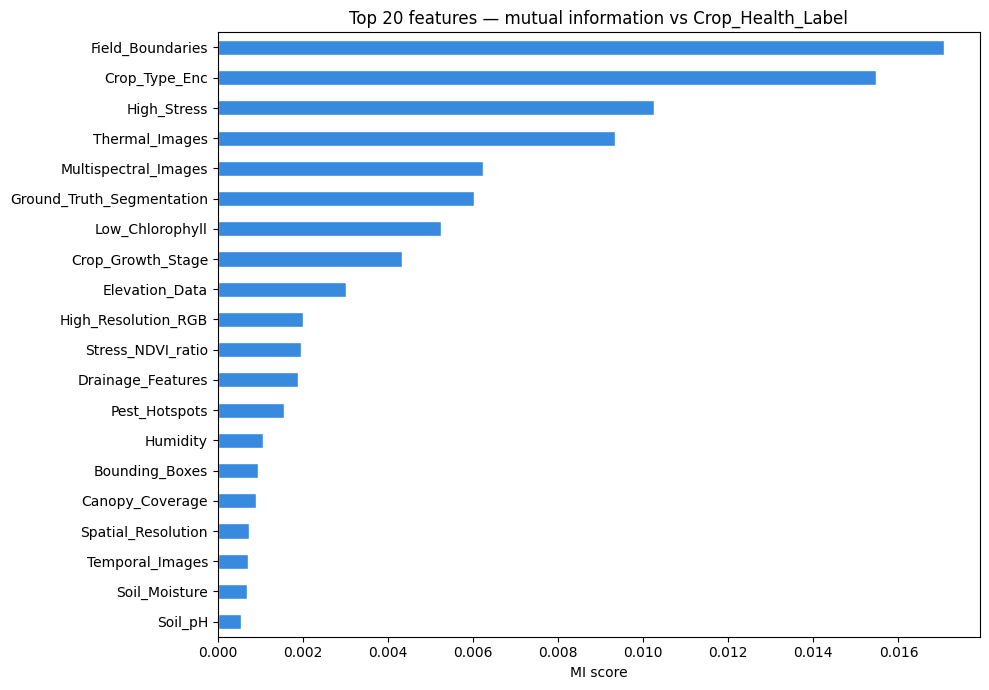

Top 15 features: ['Field_Boundaries', 'Crop_Type_Enc', 'High_Stress', 'Thermal_Images', 'Multispectral_Images', 'Ground_Truth_Segmentation', 'Low_Chlorophyll', 'Crop_Growth_Stage', 'Elevation_Data', 'High_Resolution_RGB', 'Stress_NDVI_ratio', 'Drainage_Features', 'Pest_Hotspots', 'Humidity', 'Bounding_Boxes']


In [16]:
from sklearn.feature_selection import mutual_info_classif

if TARGET in df.columns:
    mi = mutual_info_classif(X_train, y_train, random_state=42)
    mi_s = pd.Series(mi, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(10, 7))
    mi_s.head(20).sort_values().plot(kind="barh", color="#378ADD", edgecolor="white")
    plt.title("Top 20 features — mutual information vs Crop_Health_Label")
    plt.xlabel("MI score")
    plt.tight_layout(); plt.show()

    top_features = mi_s.head(15).index.tolist()
    print("Top 15 features:", top_features)


---
## Phase 5 — Modelling

### 5.1 Logistic Regression (baseline)

=== Logistic Regression ===
              precision    recall  f1-score   support

   Unhealthy       0.30      0.36      0.33     12764
     Healthy       0.70      0.64      0.67     29640

    accuracy                           0.55     42404
   macro avg       0.50      0.50      0.50     42404
weighted avg       0.58      0.55      0.56     42404

AUC-ROC: 0.4966


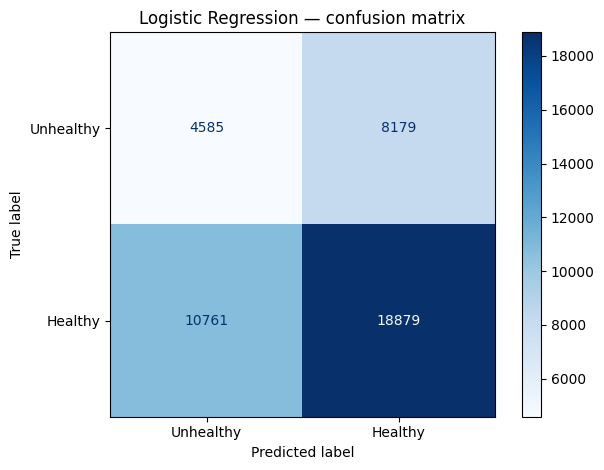

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

if TARGET in df.columns:
    lr = LogisticRegression(max_iter=500, class_weight="balanced", random_state=42)
    lr.fit(X_train_scaled, y_train_res)

    y_pred_lr = lr.predict(X_test_scaled)
    y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

    print("=== Logistic Regression ===")
    print(classification_report(y_test, y_pred_lr, target_names=["Unhealthy","Healthy"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
        display_labels=["Unhealthy","Healthy"], cmap="Blues")
    plt.title("Logistic Regression — confusion matrix")
    plt.tight_layout(); plt.show()


### 5.2 Random Forest

=== Random Forest ===
              precision    recall  f1-score   support

   Unhealthy       0.30      0.14      0.19     12764
     Healthy       0.70      0.86      0.77     29640

    accuracy                           0.64     42404
   macro avg       0.50      0.50      0.48     42404
weighted avg       0.58      0.64      0.60     42404

AUC-ROC: 0.4987


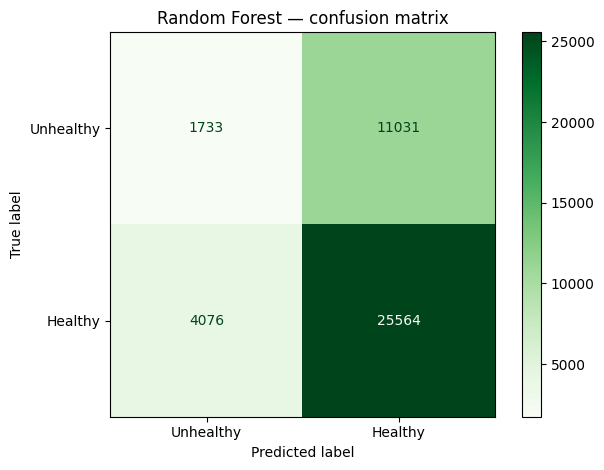

In [18]:
from sklearn.ensemble import RandomForestClassifier

if TARGET in df.columns:
    rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                 random_state=42, n_jobs=-1)
    rf.fit(X_train_res, y_train_res)

    y_pred_rf = rf.predict(X_test)
    y_prob_rf  = rf.predict_proba(X_test)[:,1]

    print("=== Random Forest ===")
    print(classification_report(y_test, y_pred_rf, target_names=["Unhealthy","Healthy"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
        display_labels=["Unhealthy","Healthy"], cmap="Greens")
    plt.title("Random Forest — confusion matrix")
    plt.tight_layout(); plt.show()


### 5.3 XGBoost

[0]	validation_0-logloss:0.69097
[50]	validation_0-logloss:0.67455
[100]	validation_0-logloss:0.67652
[150]	validation_0-logloss:0.67754
[200]	validation_0-logloss:0.67860
[250]	validation_0-logloss:0.67931
[299]	validation_0-logloss:0.67993

=== XGBoost ===
              precision    recall  f1-score   support

   Unhealthy       0.30      0.22      0.25     12764
     Healthy       0.70      0.78      0.74     29640

    accuracy                           0.61     42404
   macro avg       0.50      0.50      0.50     42404
weighted avg       0.58      0.61      0.59     42404

AUC-ROC: 0.4966


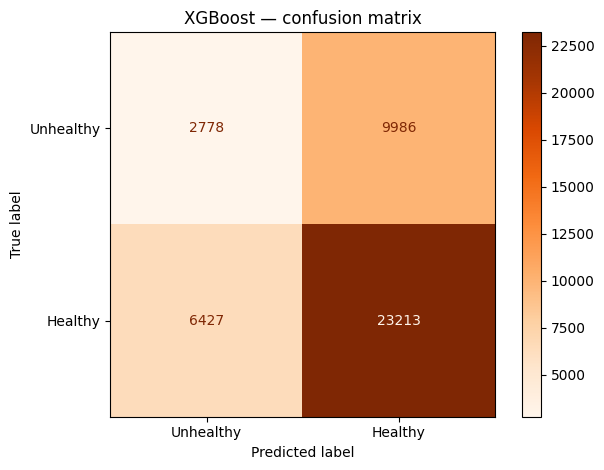

In [19]:
from xgboost import XGBClassifier

if TARGET in df.columns:
    ratio = (y_train_res == 0).sum() / (y_train_res == 1).sum()

    xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                         scale_pos_weight=ratio, eval_metric="logloss",
                         random_state=42, n_jobs=-1)
    xgb.fit(X_train_res, y_train_res,
            eval_set=[(X_test, y_test)], verbose=50)

    y_pred_xgb = xgb.predict(X_test)
    y_prob_xgb  = xgb.predict_proba(X_test)[:,1]

    print("\n=== XGBoost ===")
    print(classification_report(y_test, y_pred_xgb, target_names=["Unhealthy","Healthy"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb,
        display_labels=["Unhealthy","Healthy"], cmap="Oranges")
    plt.title("XGBoost — confusion matrix")
    plt.tight_layout(); plt.show()


### 5.4 ROC curve comparison

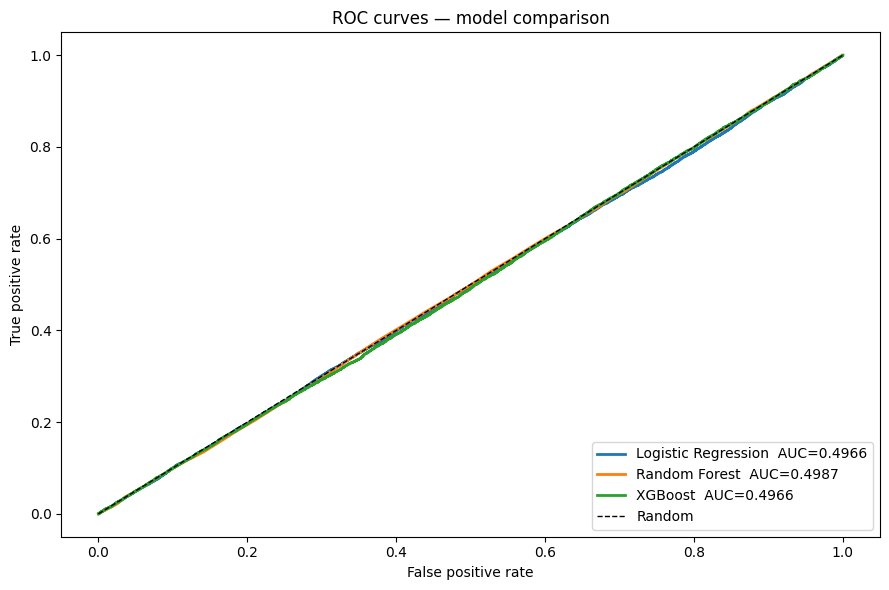

In [20]:
from sklearn.metrics import roc_curve

if TARGET in df.columns:
    plt.figure(figsize=(9,6))
    for name, yp in [("Logistic Regression",y_prob_lr),
                      ("Random Forest",      y_prob_rf),
                      ("XGBoost",            y_prob_xgb)]:
        fpr, tpr, _ = roc_curve(y_test, yp)
        auc = roc_auc_score(y_test, yp)
        plt.plot(fpr, tpr, lw=2, label=f"{name}  AUC={auc:.4f}")

    plt.plot([0,1],[0,1],"k--",lw=1,label="Random")
    plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
    plt.title("ROC curves — model comparison")
    plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()


### 5.5 Feature importance — Random Forest

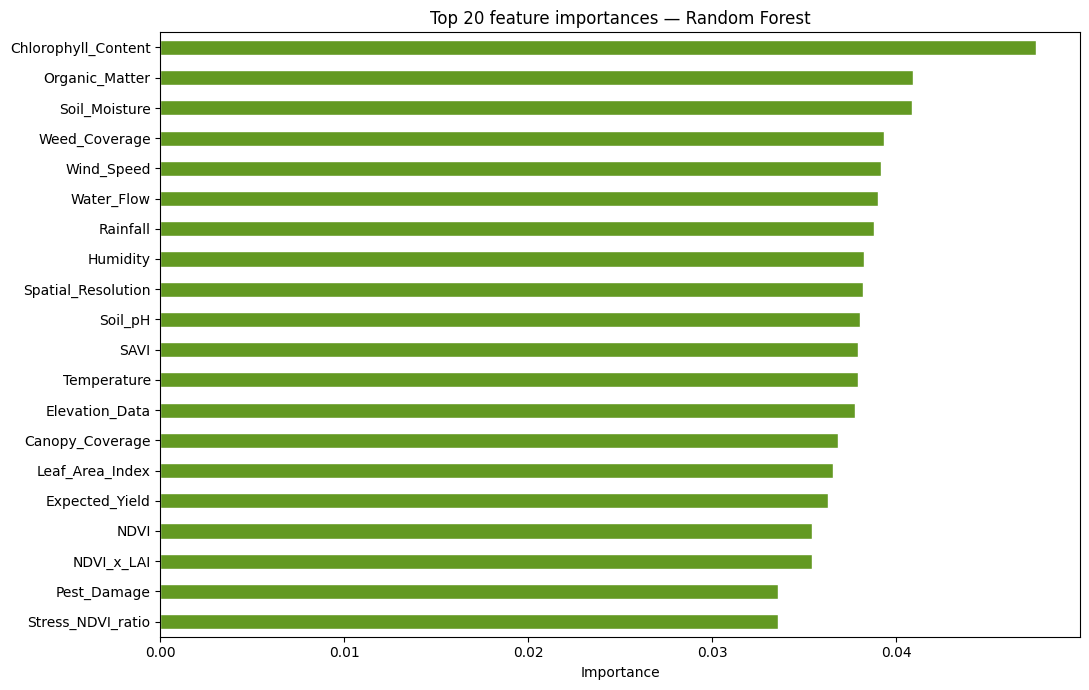

In [21]:
if TARGET in df.columns:
    fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(11, 7))
    fi.head(20).sort_values().plot(kind="barh", color="#639922", edgecolor="white")
    plt.title("Top 20 feature importances — Random Forest")
    plt.xlabel("Importance")
    plt.tight_layout(); plt.show()


### 5.6 SHAP values — XGBoost

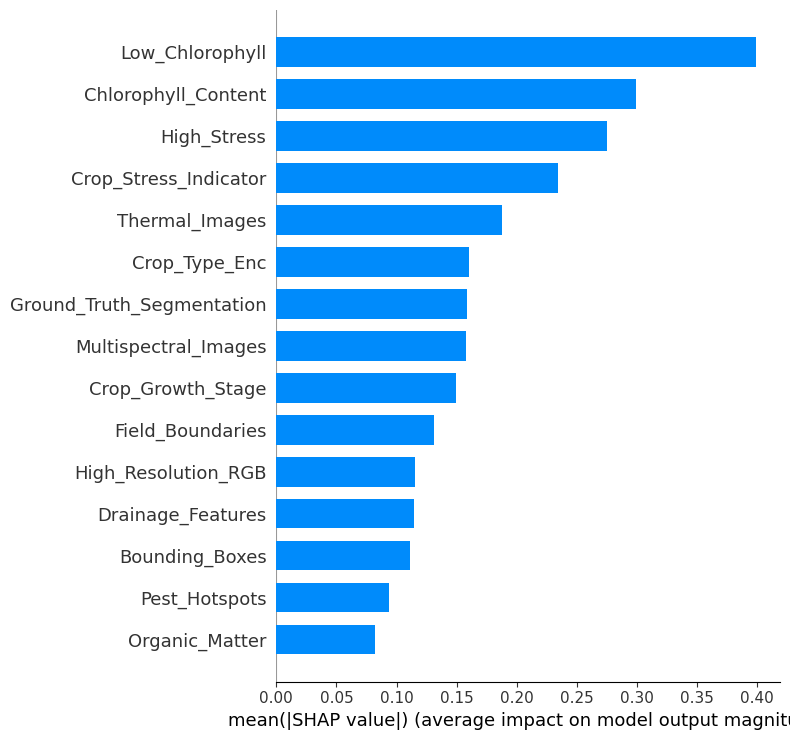

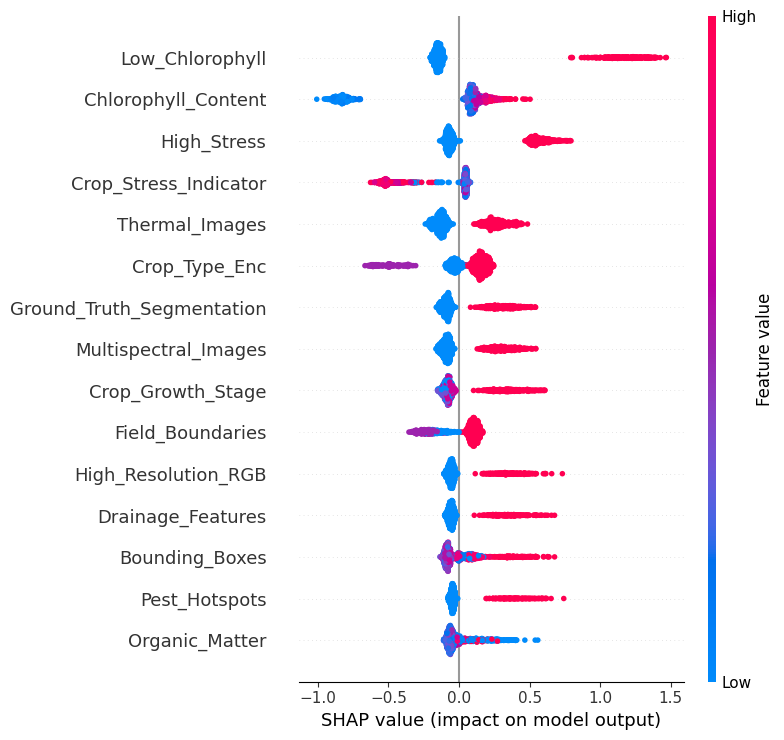

In [22]:
import shap

if TARGET in df.columns:
    explainer   = shap.TreeExplainer(xgb)
    shap_sample = X_test.sample(min(1000, len(X_test)), random_state=42)
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(shap_values, shap_sample, plot_type="bar", max_display=15, show=True)
    shap.summary_plot(shap_values, shap_sample, max_display=15, show=True)


### 5.7 Yield regression — LightGBM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.111439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5085
[LightGBM] [Info] Number of data points in the train set: 169615, number of used features: 34
[LightGBM] [Info] Start training from score 3001.728297
[50]	valid_0's l2: 4193.5
[100]	valid_0's l2: 488.65
[150]	valid_0's l2: 486.21
[200]	valid_0's l2: 500.609
[250]	valid_0's l2: 507.732
[300]	valid_0's l2: 511.014

Yield RMSE : 22.61 kg/ha
Yield R²   : 0.9992


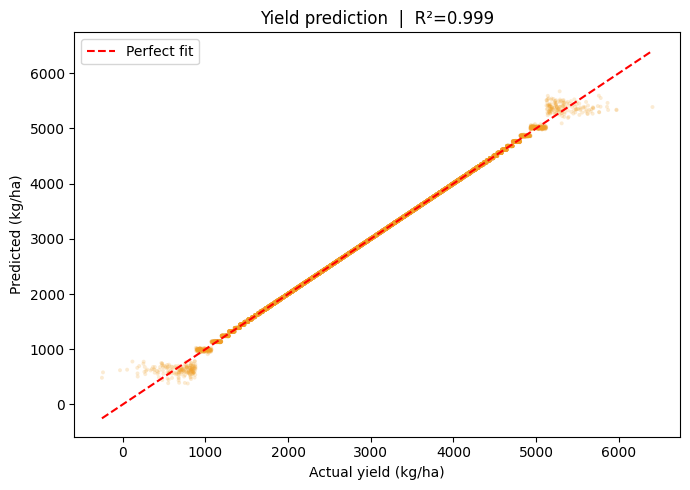

In [23]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

if "Expected_Yield" in df.columns:
    X_r = df[feature_cols].fillna(df[feature_cols].median())
    y_r = df["Expected_Yield"]

    Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

    reg = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                              num_leaves=63, random_state=42, n_jobs=-1)
    reg.fit(Xtr_r, ytr_r, eval_set=[(Xte_r, yte_r)],
            callbacks=[lgb.log_evaluation(50)])

    y_pred_yield = reg.predict(Xte_r)
    rmse = np.sqrt(mean_squared_error(yte_r, y_pred_yield))
    r2   = r2_score(yte_r, y_pred_yield)

    print(f"\nYield RMSE : {rmse:.2f} kg/ha")
    print(f"Yield R²   : {r2:.4f}")

    plt.figure(figsize=(7,5))
    plt.scatter(yte_r, y_pred_yield, alpha=0.2, s=8, color="#EF9F27", edgecolors="none")
    plt.plot([yte_r.min(),yte_r.max()],[yte_r.min(),yte_r.max()],"r--",lw=1.5,label="Perfect fit")
    plt.xlabel("Actual yield (kg/ha)"); plt.ylabel("Predicted (kg/ha)")
    plt.title(f"Yield prediction  |  R²={r2:.3f}")
    plt.legend(); plt.tight_layout(); plt.show()


### 5.8 Pest hotspot detection (imbalanced)

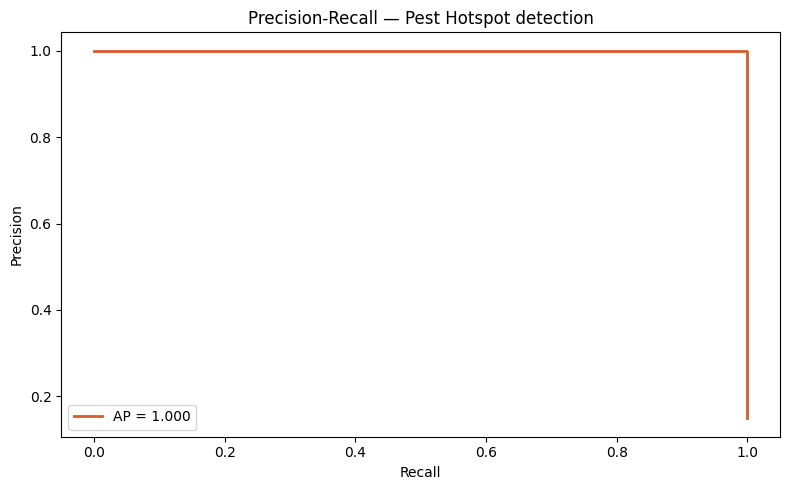

Average Precision : 1.0000
Baseline (% pest) : 0.1491


In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score

if "Pest_Hotspots" in df.columns:
    X_p = df[feature_cols].fillna(df[feature_cols].median())
    y_p = df["Pest_Hotspots"]

    Xtr_p, Xte_p, ytr_p, yte_p = train_test_split(
        X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

    rf_pest = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                      random_state=42, n_jobs=-1)
    rf_pest.fit(Xtr_p, ytr_p)
    y_prob_pest = rf_pest.predict_proba(Xte_p)[:,1]

    precision, recall, _ = precision_recall_curve(yte_p, y_prob_pest)
    ap = average_precision_score(yte_p, y_prob_pest)

    plt.figure(figsize=(8,5))
    plt.plot(recall, precision, color="#D85A30", lw=2, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision-Recall — Pest Hotspot detection")
    plt.legend(); plt.tight_layout(); plt.show()

    print(f"Average Precision : {ap:.4f}")
    print(f"Baseline (% pest) : {yte_p.mean():.4f}")


---
## Phase 6 — Reporting

### 6.1 Model performance summary

In [25]:
from sklearn.metrics import f1_score, precision_score, recall_score

if TARGET in df.columns:
    rows = []
    for name, yp, ypr in [("Logistic Regression",y_pred_lr,y_prob_lr),
                            ("Random Forest",      y_pred_rf,y_prob_rf),
                            ("XGBoost",            y_pred_xgb,y_prob_xgb)]:
        rows.append({
            "Model"    : name,
            "F1"       : round(f1_score(y_test, yp), 4),
            "Precision": round(precision_score(y_test, yp), 4),
            "Recall"   : round(recall_score(y_test, yp), 4),
            "AUC-ROC"  : round(roc_auc_score(y_test, ypr), 4),
        })

    summary_df = pd.DataFrame(rows).set_index("Model")
    summary_df.style.highlight_max(axis=0, color="#d4edda").highlight_min(axis=0, color="#f8d7da")


### 6.2 Key findings

In [26]:
print("=" * 55)
print("KEY FINDINGS")
print("=" * 55)

if TARGET in df.columns:
    if "fi" in dir():
        print("\nTop 5 drivers of crop health (RF importance):")
        for feat, imp in fi.head(5).items():
            print(f"  {feat:<35} {imp:.4f}")

    if "Crop_Type" in df.columns:
        print("\nHealth rate by crop type:")
        print(df.groupby("Crop_Type")[TARGET].mean().round(3).to_string())

    if "Crop_Growth_Stage" in df.columns:
        stage_map = {1:"Early",2:"Vegetative",3:"Flowering",4:"Maturity"}
        df["_stage"] = df["Crop_Growth_Stage"].map(stage_map)
        print("\nMean stress by growth stage:")
        if "Crop_Stress_Indicator" in df.columns:
            print(df.groupby("_stage")["Crop_Stress_Indicator"].mean().round(2).to_string())
        df.drop(columns=["_stage"], inplace=True)

if "Pest_Hotspots" in df.columns:
    print(f"\nPest hotspot prevalence : {df['Pest_Hotspots'].mean()*100:.1f}%")

if TARGET in df.columns:
    print(f"Healthy crop %          : {(df[TARGET]==1).mean()*100:.1f}%")


KEY FINDINGS

Top 5 drivers of crop health (RF importance):
  Chlorophyll_Content                 0.0476
  Organic_Matter                      0.0409
  Soil_Moisture                       0.0409
  Weed_Coverage                       0.0393
  Wind_Speed                          0.0392

Health rate by crop type:
Crop_Type
Maize    0.700
Rice     0.695
Wheat    0.699

Mean stress by growth stage:
_stage
Early         49.44
Flowering     49.55
Maturity      49.58
Vegetative    49.41

Pest hotspot prevalence : 14.9%
Healthy crop %          : 69.9%


### 6.3 Save best model

In [27]:
import joblib, json

if TARGET in df.columns:
    joblib.dump(xgb,    "crop_health_xgb_model.pkl")
    joblib.dump(scaler, "crop_health_scaler.pkl")
    with open("feature_cols.json","w") as f:
        json.dump(feature_cols, f)

    print("Saved: crop_health_xgb_model.pkl")
    print("Saved: crop_health_scaler.pkl")
    print("Saved: feature_cols.json")


Saved: crop_health_xgb_model.pkl
Saved: crop_health_scaler.pkl
Saved: feature_cols.json


### 6.4 Reusable prediction function

In [28]:
def predict_crop_health(input_dict: dict) -> dict:
    """
    Predict crop health for a single field observation.

    Parameters
    ----------
    input_dict : dict  — keys matching feature_cols

    Returns
    -------
    dict: label (0/1), probability, interpretation
    """
    row = pd.DataFrame([{col: input_dict.get(col, 0) for col in feature_cols}])
    prob  = xgb.predict_proba(row)[0][1]
    label = int(prob >= 0.5)
    return {
        "label"         : label,
        "probability"   : round(float(prob), 4),
        "interpretation": "Healthy" if label == 1 else "Unhealthy",
    }

# Quick test with first test row
if TARGET in df.columns:
    sample_obs = X_test.iloc[0].to_dict()
    result = predict_crop_health(sample_obs)
    print("Prediction :", result)
    print("Actual     :", y_test.iloc[0])


Prediction : {'label': 1, 'probability': 0.6091, 'interpretation': 'Healthy'}
Actual     : 1
